In [1]:
# Loading the Datasets (MY STEP 1)
import pandas as pd
df = pd.read_csv("Titanic-Dataset.csv")

In [2]:
# Understanding the Dataset (MY STEP 2)
print(df.head())
print(df.shape)
print(df.columns)
print(df.describe())


   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
(8

In [3]:
# Handling Missing Values (MY STEP 3)
print(df.isnull().sum())
print("Duplicate Rows: ", df.duplicated().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
Duplicate Rows:  0


In [4]:
# Filling Missing Values (MY STEP 4)
df['Age'] = df['Age'].fillna(df['Age'].median())

df['Cabin_known'] = df['Cabin'].notna().astype(int)
df = df.drop(columns=['Cabin','PassengerId'])

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [14]:
# (MY STEP 5)
print(df.dtypes)

# Get numeric columns (integers and floats)
num_cols = df.select_dtypes(include=['number']).columns.tolist()

# Get categorical columns (strings, objects, or category data types)
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Print the results
print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)


Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Embarked        object
Cabin_known      int64
dtype: object
Numerical Columns: ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Cabin_known']
Categorical Columns: ['Name', 'Sex', 'Ticket', 'Embarked']


In [6]:
# Confirming Missing Values (MY STEP 6)
print(df.isnull().sum())
print("Duplicate Rows: ", df.duplicated().sum())

Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Cabin_known    0
dtype: int64
Duplicate Rows:  0


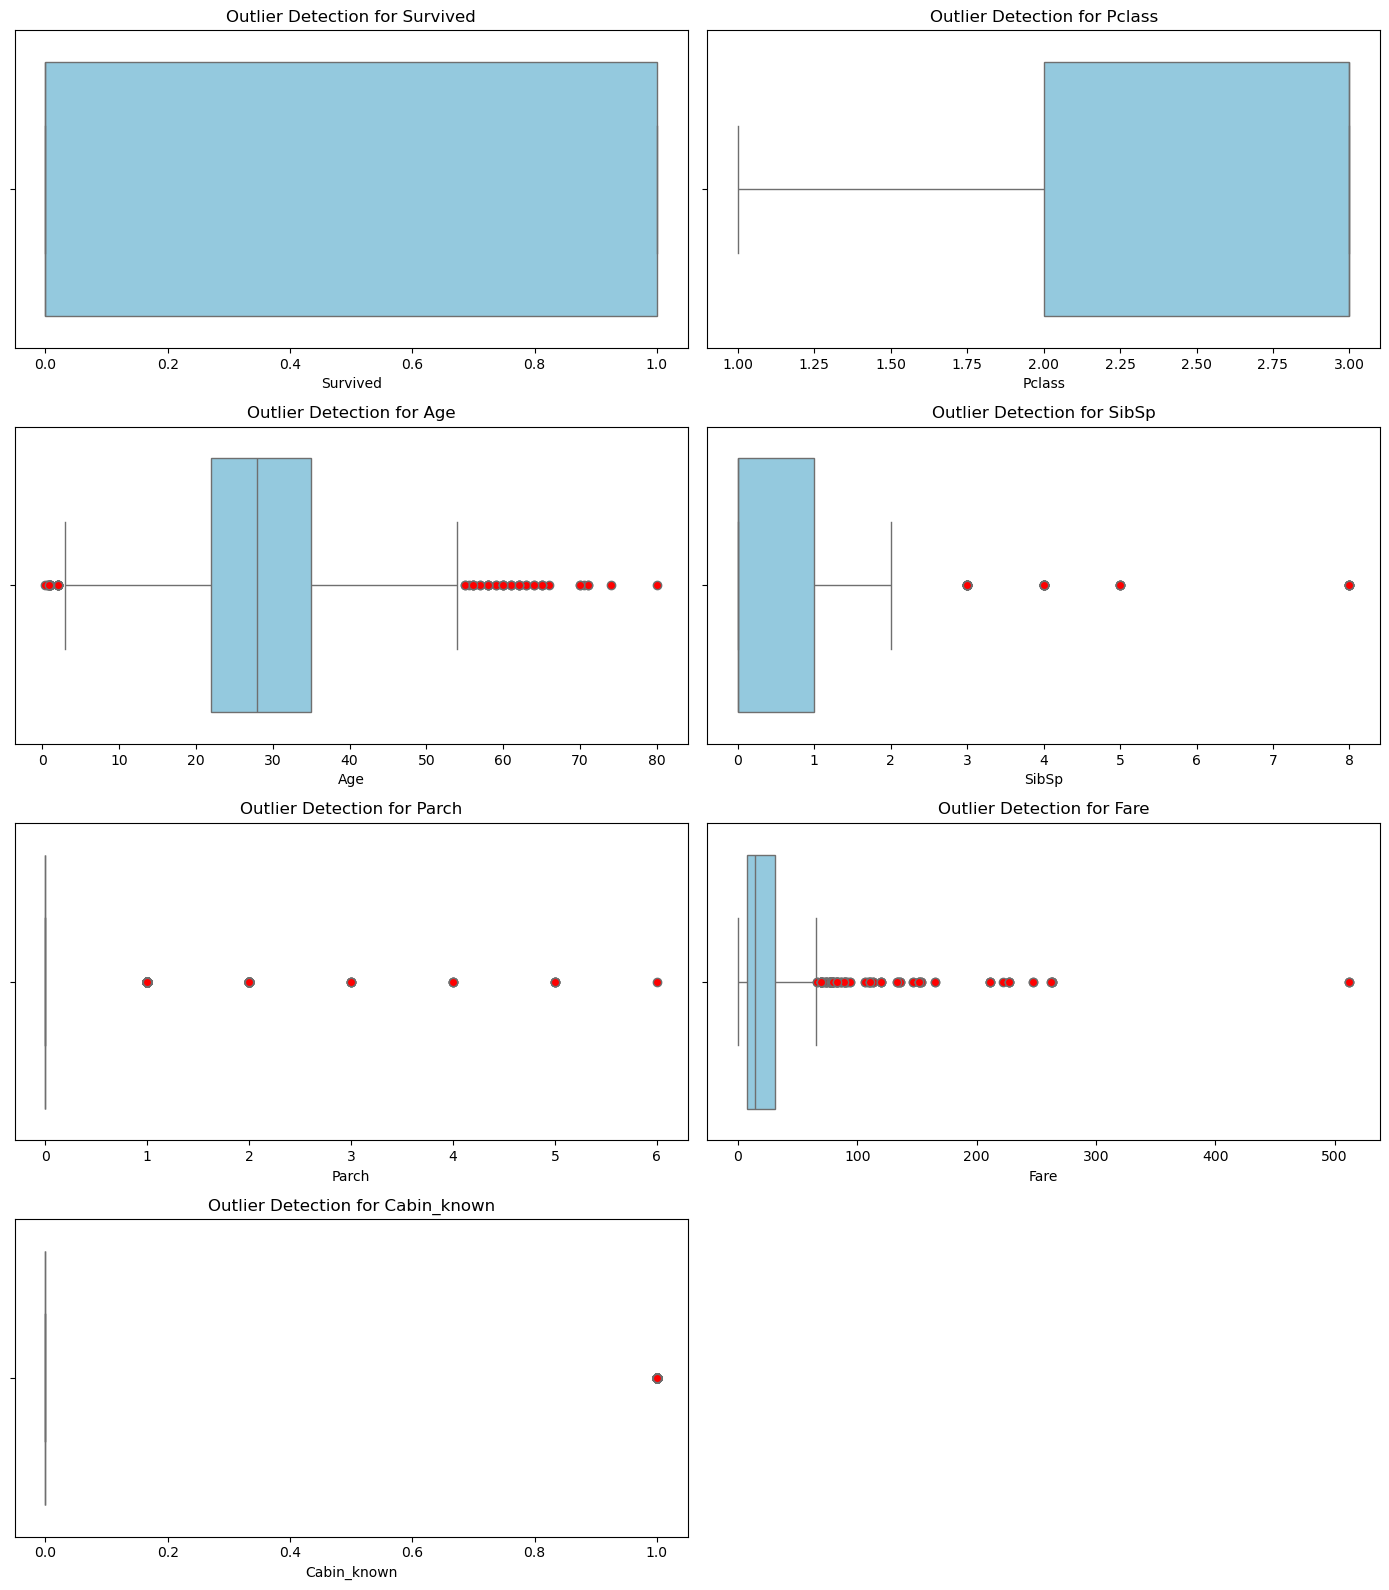

In [21]:
# Outlier Detection
import math
import matplotlib.pyplot as plt
import seaborn as sns

# Define your numerical columns (e.g., from your dataset)
# Replace these with your actual numeric column names
num_columns = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Cabin_known']

# 1. Automatically calculate grid size based on column count
num_plots = len(num_columns)
cols_per_row = 2
rows_needed = math.ceil(num_plots / cols_per_row)

# 2. Setup figure dimensions dynamically
plt.figure(figsize=(14, 4 * rows_needed))

for i, column in enumerate(num_columns, 1):
    plt.subplot(rows_needed, cols_per_row, i)

    # 3. Use Seaborn's boxplot to clearly show outliers as dots
    sns.boxplot(x=df[column], color="skyblue", flierprops={"markerfacecolor": "red", "marker": "o"})

    plt.xlabel(column)
    plt.title(f"Outlier Detection for {column}")

# Clean layout spacing so text elements don't overlap
plt.tight_layout()
plt.show()


In [22]:
# Calculate the IQR boundaries (My Step 8)

for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    print(f'{column}')
    print(f'Q1: {Q1}')
    print(f'Q3: {Q3}')
    print(f'IQR: {IQR}')
    print(f'Lower Bound: {lower_bound}')
    print(f'Upper Bound: {upper_bound}')
    print('-' * 40)

Survived
Q1: 0.0
Q3: 1.0
IQR: 1.0
Lower Bound: -1.5
Upper Bound: 2.5
----------------------------------------
Pclass
Q1: 2.0
Q3: 3.0
IQR: 1.0
Lower Bound: 0.5
Upper Bound: 4.5
----------------------------------------
Age
Q1: 22.0
Q3: 35.0
IQR: 13.0
Lower Bound: 2.5
Upper Bound: 54.5
----------------------------------------
SibSp
Q1: 0.0
Q3: 1.0
IQR: 1.0
Lower Bound: -1.5
Upper Bound: 2.5
----------------------------------------
Parch
Q1: 0.0
Q3: 0.0
IQR: 0.0
Lower Bound: 0.0
Upper Bound: 0.0
----------------------------------------
Fare
Q1: 7.9104
Q3: 31.0
IQR: 23.0896
Lower Bound: -26.724
Upper Bound: 65.6344
----------------------------------------
Cabin_known
Q1: 0.0
Q3: 0.0
IQR: 0.0
Lower Bound: 0.0
Upper Bound: 0.0
----------------------------------------


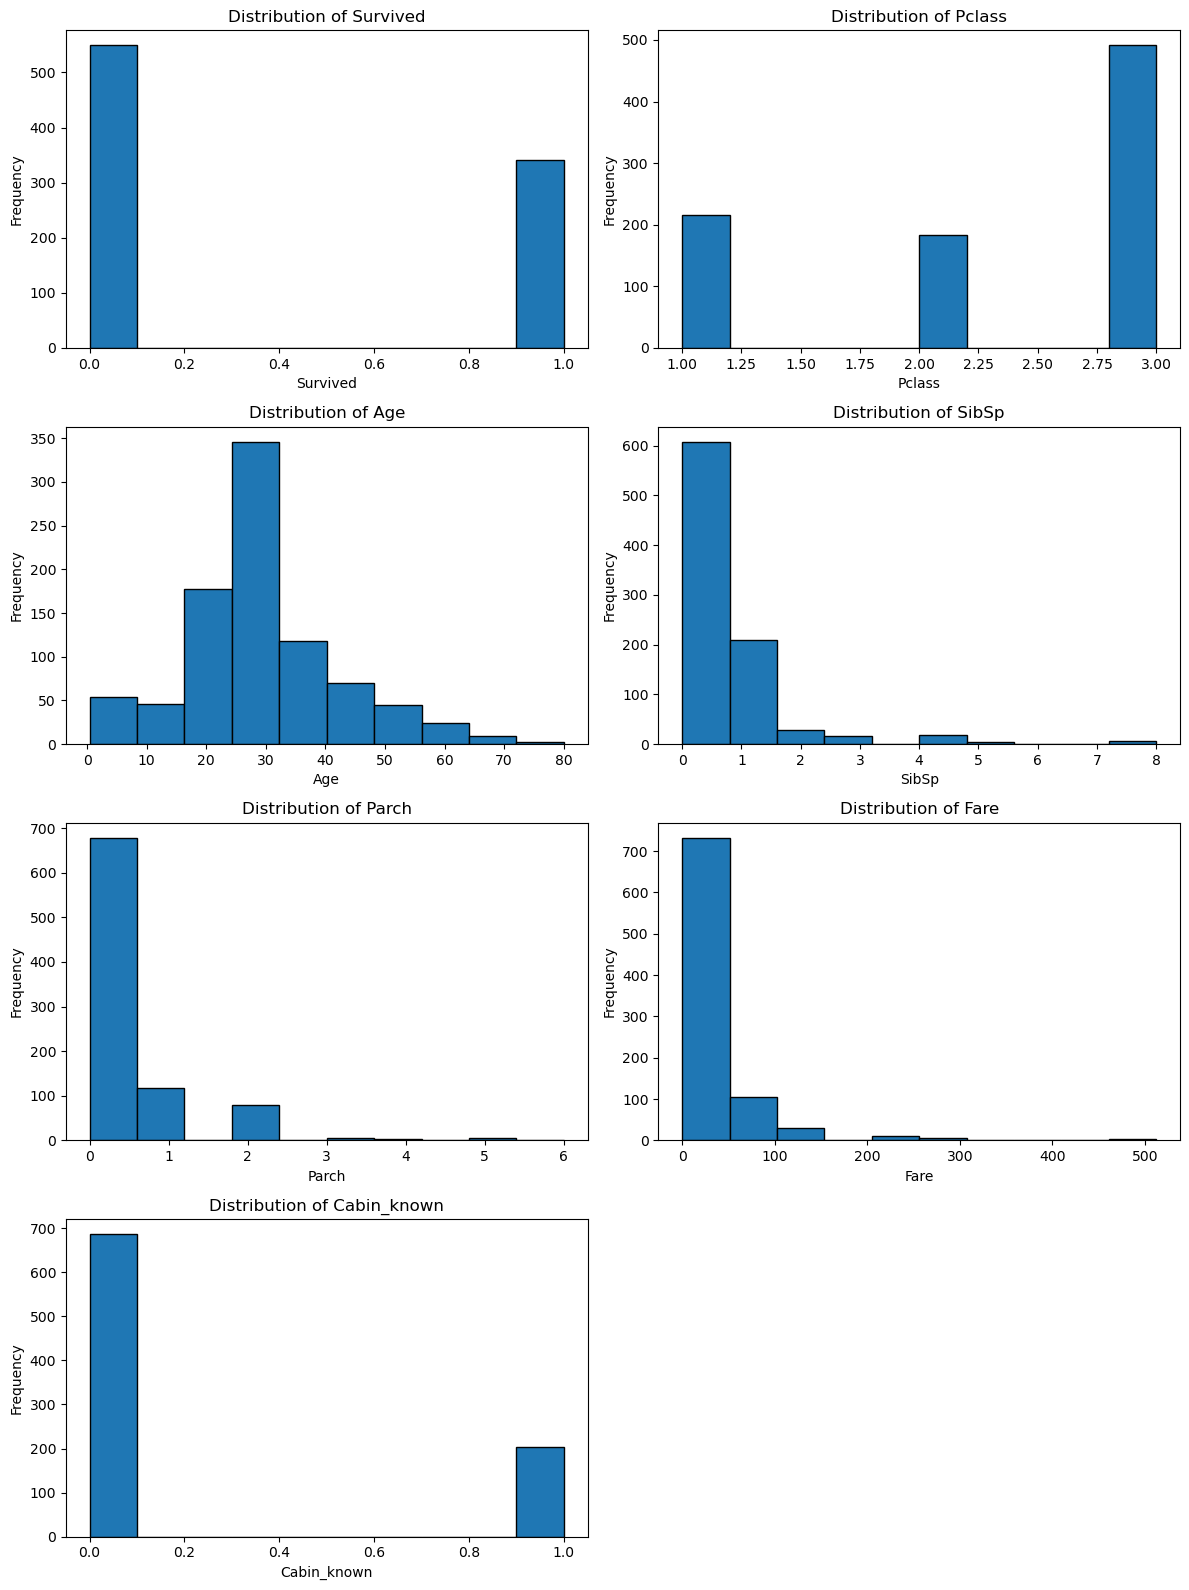

In [16]:
# Univariate Analysis (My Step 9)
import math
import matplotlib.pyplot as plt

# calculating grid size based on your column count
num_plots = len(columns)
cols_per_row = 2 
rows_needed = math.ceil(num_plots / cols_per_row)

#Dynamic figure dimensions based on rows needed
plt.figure(figsize=(12, 4 * rows_needed))

for i, column in enumerate(columns, 1):
    # Dynamically set the grid dimensions based on rows_needed
    plt.subplot(rows_needed, cols_per_row, i)

    # Plot the histogram (dropping NaN values prevents other plot errors)
    plt.hist(df[column].dropna(), bins=10, edgecolor="black")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {column}")

# Clean layout spacing so titles don't overlap axes
plt.tight_layout()
plt.show()


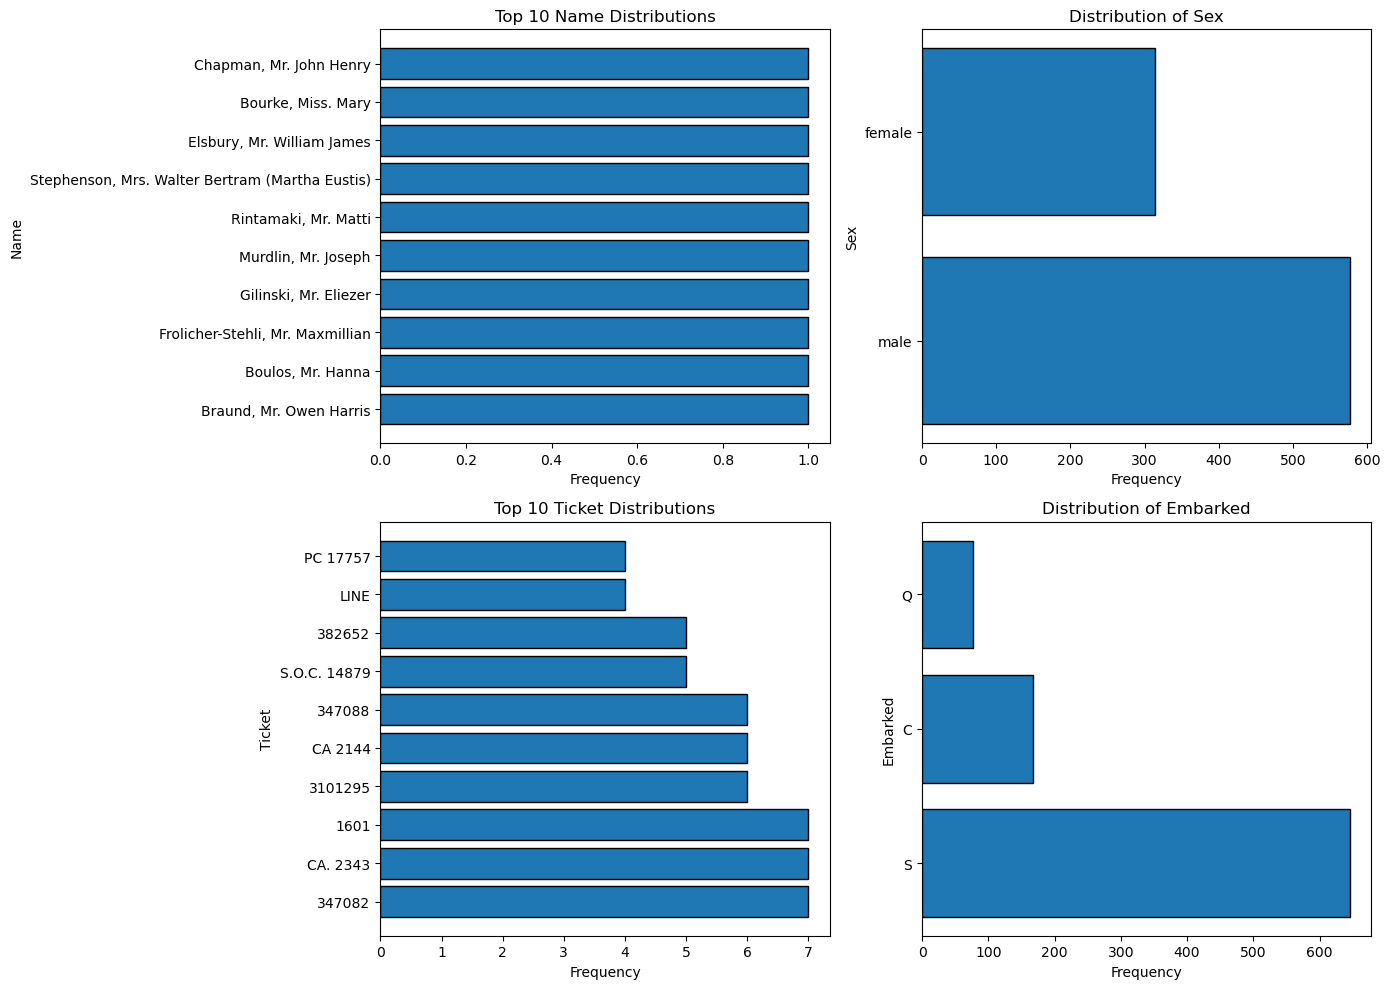

In [17]:
# Univariate Analysis (My Step 9)
import math
import matplotlib.pyplot as plt

cat_columns = ["Name", "Sex", "Ticket", "Embarked"]

# Automatically calculate grid size based on column count
num_plots = len(cat_columns)
cols_per_row = 2
rows_needed = math.ceil(num_plots / cols_per_row)

# Dynamic figure size based on the rows needed
plt.figure(figsize=(14, 5 * rows_needed))

for i, column in enumerate(cat_columns, 1):
    plt.subplot(rows_needed, cols_per_row, i)

    # Get the value counts of the category (Top 10 to keep it clean)
    data_counts = df[column].value_counts().head(10)

    # Plot as a horizontal bar chart so long string labels are readable
    plt.barh(data_counts.index.astype(str), data_counts.values, edgecolor="black")

    plt.ylabel(column)
    plt.xlabel("Frequency")
    # Subtitle specifies if we're looking at a truncated top-10 list
    if df[column].nunique() > 10:
        plt.title(f"Top 10 {column} Distributions")
    else:
        plt.title(f"Distribution of {column}")

# Clean layout spacing so text elements don't overlap
plt.tight_layout()
plt.show()


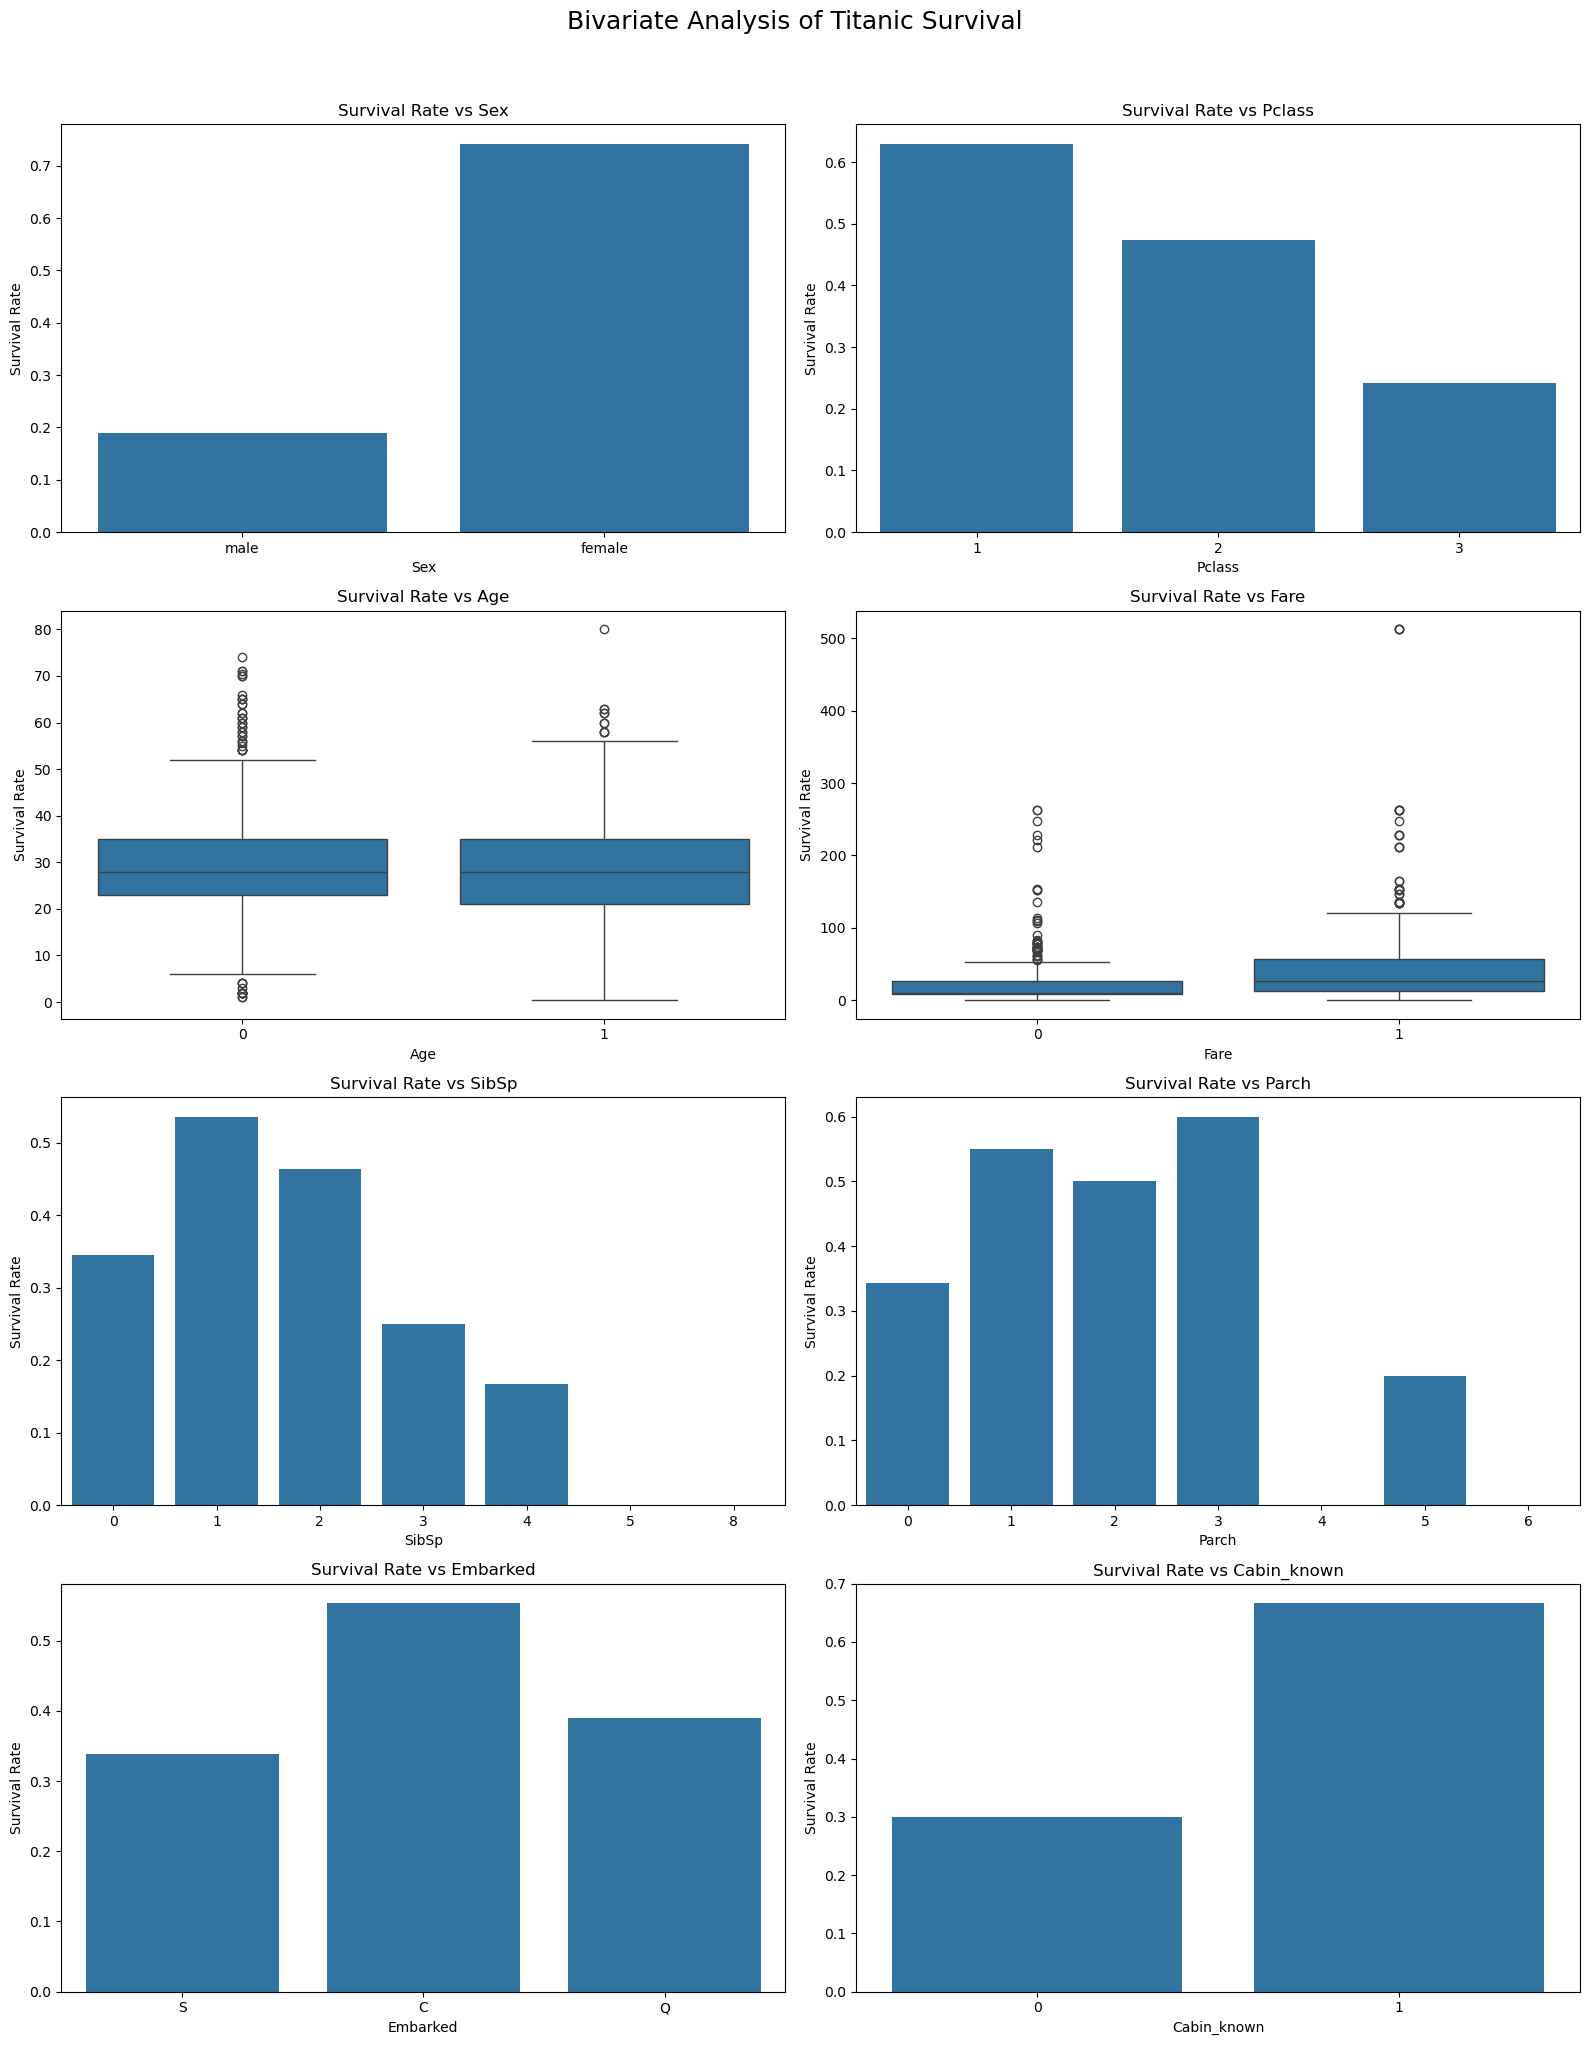

In [25]:
# Bivariate Analysis (My Step 10)
import matplotlib.pyplot as plt
import seaborn as sns

features = [
    "Sex",
    "Pclass",
    "Age",
    "Fare",
    "SibSp",
    "Parch",
    "Embarked",
    "Cabin_known"
]

fig, axes = plt.subplots(4, 2, figsize=(16, 20))

for ax, feature in zip(axes.flatten(), features):

    if feature in ["Age", "Fare"]:
        sns.boxplot(
            data=df,
            x="Survived",
            y=feature,
            ax=ax
        )

    else:
        sns.barplot(
            data=df,
            x=feature,
            y="Survived",
            ax=ax,
            errorbar=None
        )

    ax.set_title(f"Survival Rate vs {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Survival Rate")

plt.suptitle(
    "Bivariate Analysis of Titanic Survival",
    fontsize=18,
    y=1.02
)

plt.tight_layout()
plt.show()

             Survived    Pclass       Age     SibSp     Parch      Fare  \
Survived     1.000000 -0.338481 -0.064910 -0.035322  0.081629  0.257307   
Pclass      -0.338481  1.000000 -0.339898  0.083081  0.018443 -0.549500   
Age         -0.064910 -0.339898  1.000000 -0.233296 -0.172482  0.096688   
SibSp       -0.035322  0.083081 -0.233296  1.000000  0.414838  0.159651   
Parch        0.081629  0.018443 -0.172482  0.414838  1.000000  0.216225   
Fare         0.257307 -0.549500  0.096688  0.159651  0.216225  1.000000   
Cabin_known  0.316912 -0.725541  0.240314 -0.040460  0.036987  0.482075   

             Cabin_known  
Survived        0.316912  
Pclass         -0.725541  
Age             0.240314  
SibSp          -0.040460  
Parch           0.036987  
Fare            0.482075  
Cabin_known     1.000000  


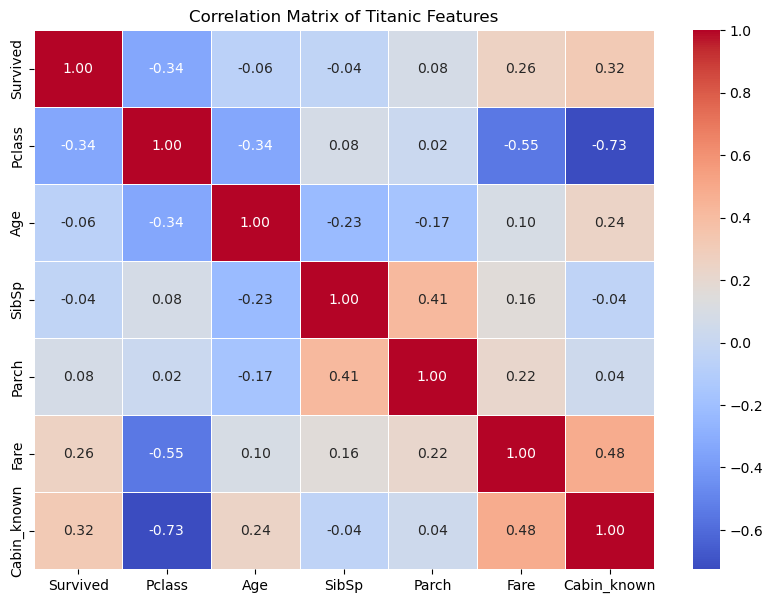

In [27]:
# Correlation Analysis (My Step 11)
numeric_features = [
    "Survived",
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Cabin_known"
]
correlation_matrix = df[numeric_features].corr()

print(correlation_matrix)
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Titanic Features")
plt.show()

In [28]:
# Extract correlations specifically with Survived (My Step 12)

survival_correlation = (
    correlation_matrix["Survived"]
    .sort_values(ascending=False)
)

survival_correlation

Survived       1.000000
Cabin_known    0.316912
Fare           0.257307
Parch          0.081629
SibSp         -0.035322
Age           -0.064910
Pclass        -0.338481
Name: Survived, dtype: float64

In [29]:
# Feature Selection (My Step 11)
features = [
    "Sex",
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
    "Cabin_known"
]
target = "Survived"